# Network statistics

Summary numbers for the character network built from `characters_enriched.csv` — the figures that go into the *"what is the network you're analyzing?"* section of the report.

The graph is rebuilt from scratch here so this notebook is self-contained.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

## 1. Build the graph

In [2]:
df = pd.read_csv('../csvs/characters_enriched.csv')
valid_ids = set(df['ID'].dropna().astype(str))

edges = set()
for row in tqdm(df.itertuples(index=False), total=len(df), desc='Edges'):
    src = row.ID
    if not isinstance(src, str) or src not in valid_ids:
        continue
    aff = row.affiliated
    if not isinstance(aff, str):
        continue
    for tgt in aff.split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in valid_ids:
            edges.add(frozenset((src, tgt)))

G = nx.Graph()
for row in df.itertuples(index=False):
    if isinstance(row.ID, str):
        G.add_node(
            row.ID,
            name=row.name if isinstance(row.name, str) else row.ID,
            allegiance=row.allegiance if isinstance(row.allegiance, str) else '',
        )
for e in edges:
    a, b = tuple(e)
    G.add_edge(a, b)

LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'LCC:   {LCC.number_of_nodes()} nodes, {LCC.number_of_edges()} edges')

Edges: 100%|██████████| 3690/3690 [00:00<00:00, 127307.12it/s]

Graph: 3690 nodes, 36315 edges
LCC:   3485 nodes, 36273 edges


## 2. Size, density, components

In [3]:
degs = np.array([d for _, d in G.degree()])

basic = {
    'Nodes': G.number_of_nodes(),
    'Edges': G.number_of_edges(),
    'Density': round(nx.density(G), 6),
    'Isolates': int((degs == 0).sum()),
    'Connected components': nx.number_connected_components(G),
    'LCC nodes': LCC.number_of_nodes(),
    'LCC edges': LCC.number_of_edges(),
    'LCC coverage': f'{LCC.number_of_nodes() / G.number_of_nodes():.1%}',
}
pd.Series(basic, name='value').to_frame()

,value
Nodes,3690
Edges,36315
Density,0.005336
Isolates,154
Connected components,173
LCC nodes,3485
LCC edges,36273
LCC coverage,94.4%


## 3. Degree distribution

In [4]:
degree_stats = {
    'Min': int(degs.min()),
    'Max': int(degs.max()),
    'Mean': round(float(degs.mean()), 2),
    'Median': int(np.median(degs)),
    'Std': round(float(degs.std()), 2),
}
pd.Series(degree_stats, name='degree').to_frame()

,degree
Min,0.00
Max,465.00
Mean,19.68
Median,8.00
Std,35.35


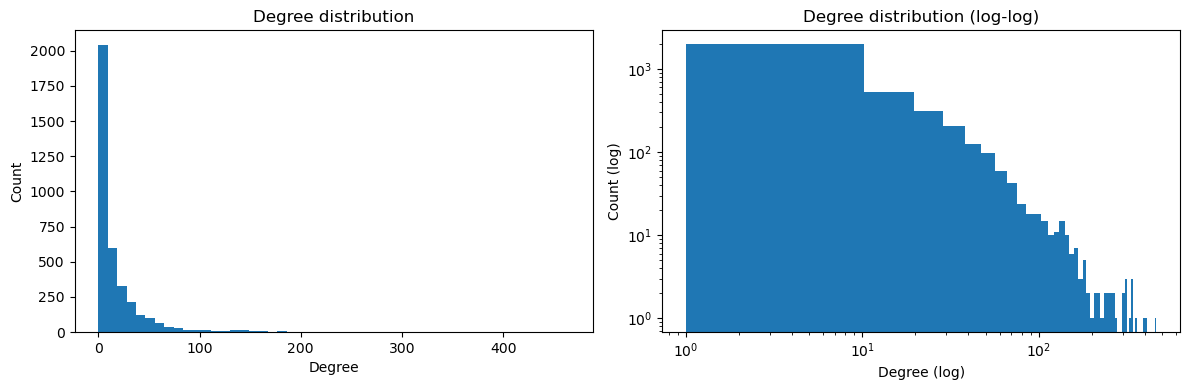

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(degs, bins=50)
ax[0].set_xlabel('Degree'); ax[0].set_ylabel('Count')
ax[0].set_title('Degree distribution')

ax[1].hist(degs[degs > 0], bins=50)
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_xlabel('Degree (log)'); ax[1].set_ylabel('Count (log)')
ax[1].set_title('Degree distribution (log-log)')
plt.tight_layout()
plt.show()

In [6]:
top = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:20]
pd.DataFrame(
    [(G.nodes[i].get('name', i), d, G.nodes[i].get('allegiance', '')) for i, d in top],
    columns=['name', 'degree', 'allegiance'],
)

,name,degree,allegiance
0,Tyrion Lannister,465,House_Lannister;Second_Sons
1,Jaime Lannister,409,House_Lannister;Kingsguard
2,Stannis Baratheon,391,
3,Tywin Lannister,356,House_Lannister
4,Eddard Stark,344,House_Stark
5,Cersei Lannister,342,House_Lannister;House_Baratheon_of_King's_Landing
6,Joffrey Baratheon,336,
7,Jon Snow,331,House_Stark;Night's_Watch
8,Robb Stark,312,
9,Jaehaerys I Targaryen,311,


## 4. Clustering & assortativity

In [7]:
struct = {
    'Avg clustering (local)': round(nx.average_clustering(G), 4),
    'Transitivity (global clustering)': round(nx.transitivity(G), 4),
    'Degree assortativity': round(nx.degree_assortativity_coefficient(G), 4),
    'Allegiance assortativity': round(
        nx.attribute_assortativity_coefficient(G, 'allegiance'), 4
    ),
}
pd.Series(struct, name='value').to_frame()

,value
Avg clustering (local),0.5620
Transitivity (global clustering),0.2769
Degree assortativity,-0.0383
Allegiance assortativity,0.1490


## 5. Shortest paths & diameter (LCC)

Path-based metrics only make sense on a connected graph, so we use the LCC. The mean path length is estimated from a BFS sample for speed — swap in `nx.average_shortest_path_length(LCC)` for the exact value.

In [8]:
sample_size = min(300, LCC.number_of_nodes())
rng = np.random.default_rng(42)
sample = rng.choice(list(LCC.nodes()), size=sample_size, replace=False)

lengths = []
for src in tqdm(sample, desc='Sampled BFS'):
    lengths.extend(nx.single_source_shortest_path_length(LCC, src).values())

paths = {
    f'Mean shortest path (sampled, {sample_size} sources)': round(float(np.mean(lengths)), 3),
    'Diameter (LCC, exact)': nx.diameter(LCC),
}
pd.Series(paths, name='value').to_frame()

Sampled BFS: 100%|██████████| 300/300 [00:00<00:00, 328.99it/s]


,value
"Mean shortest path (sampled, 300 sources)",3.189
"Diameter (LCC, exact)",14.000


## 6. Node attributes

What metadata is attached to each node, and how populated is it?

In [9]:
attrs = ['name', 'allegiance']
coverage = {
    a: sum(1 for _, v in G.nodes(data=a) if isinstance(v, str) and v)
    for a in attrs
}
pd.DataFrame({
    'attribute': attrs,
    'populated': [coverage[a] for a in attrs],
    'coverage': [f'{coverage[a] / G.number_of_nodes():.1%}' for a in attrs],
})

,attribute,populated,coverage
0,name,3690,100.0%
1,allegiance,2990,81.0%
